# Material Balances

1. Water enters a 2.00-m3 tank at a rate of 6.00 kg/s and is withdrawn at a rate of 3.00 kg/s. The tank is initially half full.
<ol type="a">
<li> Write a mass balance for the process. Identify the terms of the general balance equation present in your equation and state the reason for omitting any terms.
<li> How long will the tank take to overﬂow?
</ol>

Using an integral balance, and assuming a constant rate for input, generation (consumption) and outputs:

$$M_{accumulated} = F_{input}\Delta t - F_{output} \Delta t + G \Delta t$$

In addition, $G=0$ because no water is generated inside the tank:

$$M_{accumulated} = (F_{input} - F_{output}) \Delta t$$

Knowing that the tank starts half full, then $M_{accumulated} = M_{full} - M_0$ and that $M_t = V_t.\rho$, where the subscript $t$ is the value of the variable at any time $t$, $\rho$ is the density of the liquid, and $V$ stand for volume:

$$\rho(V_{full} - V_0) = (F_{input} - F_{output}) \Delta t \to \Delta t = \frac{\rho(V_{full} - V_0)}{(F_{input} - F_{output})}$$

In [1]:
from src.material_balances.simple_material_balances import SimpleMaterialBalancer

In [2]:
rho = 1000                          # density of water (kg/m3)
Vfinal = 2                          # final tank volume (m3)
k = 0.5                             # fraction of tank level
volume_list = [k * Vfinal, Vfinal]  # states in time for the volume of the tank (m3)
Finput = 6                          # input of water (kg/s)
Foutput = 3                         # output of water (kg/s)

balancer = SimpleMaterialBalancer
time = balancer.time_to_fill_liquid_tank(
    rho=rho,
    volume_list=volume_list,
    mass_input=Finput,
    mass_output=Foutput
)

print('Time to fill the tank: %.2f s or %.2f minutes'%(time, time / 60))


Initial tank volume (m3): 1.00
Full tank volume (m3): 2.00
Delta volume in tank (m3): 1.00
Rate of mass input (kg/s): 6.00
Rate of mass output (kg/s): 3.00
Time to fill the tank: 333.33 s or 5.56 minutes


<ol start="2">
<li> A stream consisting of 44.6 mole% benzene and 55.4% toluene is fed at a constant rate to a process unit that produces two product streams, one a vapor and the other a liquid. The vapor ﬂow rate is initially
zero and asymptotically approaches half of the molar ﬂow rate of the feed stream. Throughout this entire period, no material accumulates in the unit. When the vapor ﬂow rate has become constant, the liquid is analyzed and found to be 28.0 mole% benzene.
<ol type="a">
<li> For a feed rate of 100 mol/min, draw and fully label a ﬂowchart for the process after the vapor ﬂow rate has reached its limiting value, and then use balances to calculate the molar ﬂow rate of the liquid and the composition of the vapor in mole fractions.
</ol>
</ol>

We can write differential material balances for: the total system, the benzene, and the toluene. The dots represent temporal rates:

$$\dot{M}_{accumulation} = \dot{M}_{input} - \dot{M}_output + \dot{G} - \dot{C}$$

Considering the following:
- No chemical reaction occurs inside the process unit, so $\dot{G}=$ and $\dot{C}=0$ for any chemical species;
- there's no accumulation during stationary regime, so $\dot{M}_{accumulation} = 0$ for any chemical species;
- there is a single input stream and two output streams in this system. Choosing the toluene component and the benzene component:

$$0 = z_{toluene}\dot{F}_{input} - y_{toluene}\dot{V}_{output} - x_{toluene}\dot{L}_{output}$$
$$0 = z_{benzene}\dot{F}_{input} - y_{benzene}\dot{V}_{output} - x_{benzene}\dot{L}_{output}$$

Where:
- $z_i$ is the molar composition of component $i$ at input
- $y_i$ is the molar composition of component $i$ at vapor output
- $x_i$ is the molar composition of component $i$ at liquid output
- $\dot{F}, \dot{V}, \dot{L}$ are the molar flow rates of the streams in mol/min
- since all the streams are binary mixtures: $y_{benzene} + y_{toluene} = 1$. Stands for all strams compositions

Replacing every knwon information, and reorganizing everything:

$$(1-y_{benzene})\dot{V}_{output} - (1-x_{benzene})\dot{L}_{output} = z_{toluene}\dot{F}_{input}$$
$$y_{benzene}\dot{V}_{output} - x_{benzene}\dot{L}_{output} = z_{benzene}\dot{F}_{input}$$

We remain with 3 unknown variables, $y_{benzene}, \dot{V}_{output}, \dot{L}_{output}$, which would made this system impossible to be solved. However, the text mentions that in stationary state, $\dot{V}=k\dot{F}_{input}$. Hence, we can replace this and get:

$$(1-y_{benzene})(k\dot{F}_{input}) - (1-x_{benzene})\dot{L}_{output} = z_{toluene}\dot{F}_{input}$$
$$y_{benzene}(k\dot{F}_{input}) - x_{benzene}\dot{L}_{output} = z_{benzene}\dot{F}_{input}$$

Which is a linear system of 2 equations and 2 variables and can be rewritten as:

$$-k\dot{F}_{input}y_{benzene} - (1-x_{benzene})\dot{L}_{output} = z_{toluene}\dot{F}_{input} - k\dot{F}_{input}$$
$$y_{benzene}(k\dot{F}_{input}) - x_{benzene}\dot{L}_{output} = z_{benzene}\dot{F}_{input}$$

$$\begin{bmatrix}-k\dot{F}_{input} & (1-x_{benzene}) \\ k\dot{F}_{input} & x_{benzene}\end{bmatrix}\begin{bmatrix}y_{benzene} \\ \dot{L}_{output}\end{bmatrix} = \begin{bmatrix}(z_{toluene} - k)\dot{F}_{input} \\ z_{benzene}\dot{F}_{input}\end{bmatrix}$$

After solving such system, we obtain directly $y_{benzene}, \dot{L}_{output}$. Applying the additional relationships, we got:

- $y_{toluene} = 1 - y_{benzene}$
- $x_{toluene} = 1 - x_{benzene}$
- $\dot{F}_{input} = \dot{V}_{output} + \dot{L}_{output}$ (material balance check)

In [3]:
z_benzene=0.446                                             # benzene molar fraction at input stream
separation_results = balancer.binary_mixture_separation_vl(
    input_molar_flow=100,                                   # molar flow of input stream (mol/min)
    x_1=0.28,                                               # benzene molar fraction at steady state
    k=0.5,                                                  # vapor stream fraction in respect to total input flow rate at steady state
    z=[z_benzene, 1-z_benzene]
)



In [4]:
print("="*50)
print(" MATERIAL BALANCE REPORT (Steady State) ")
print("="*50)
for stream_name, data in separation_results.items():
    print(f"--- {stream_name.upper()} STREAM ---")
    print(f"Total Molar Flow : {data["molar_flow_mol_min"]:>6.2f} mol/min")
    print("Molar Fractions  :")
    print(f"  - Benzene      : {data["molar_fraction_list"][0]:>6.4f}")
    print(f"  - Toluene      : {data["molar_fraction_list"][1]:>6.4f}")
    print("Component Flows  (mol/min):")
    print(f"  - Benzene      : {data["molar_flow_by_component"][0]:>6.2f}")
    print(f"  - Toluene      : {data["molar_flow_by_component"][1]:>6.2f}")
    print()


 MATERIAL BALANCE REPORT (Steady State) 
--- INPUT STREAM ---
Total Molar Flow : 100.00 mol/min
Molar Fractions  :
  - Benzene      : 0.4460
  - Toluene      : 0.5540
Component Flows  (mol/min):
  - Benzene      :  44.60
  - Toluene      :  55.40

--- VAPOR STREAM ---
Total Molar Flow :  50.00 mol/min
Molar Fractions  :
  - Benzene      : 0.6120
  - Toluene      : 0.3880
Component Flows  (mol/min):
  - Benzene      :  30.60
  - Toluene      :  19.40

--- LIQUID STREAM ---
Total Molar Flow :  50.00 mol/min
Molar Fractions  :
  - Benzene      : 0.2800
  - Toluene      : 0.7200
Component Flows  (mol/min):
  - Benzene      :  14.00
  - Toluene      :  36.00



<ol start="3">
<li> A distillation column is a process unit in which a feed mixture is separated by multiple partial vaporizations and condensations to form two or more product streams. The overhead product stream is
rich in the most volatile components of the feed mixture (the ones that vaporize most readily), and the
bottom product stream is rich in the least volatile components.
</ol>

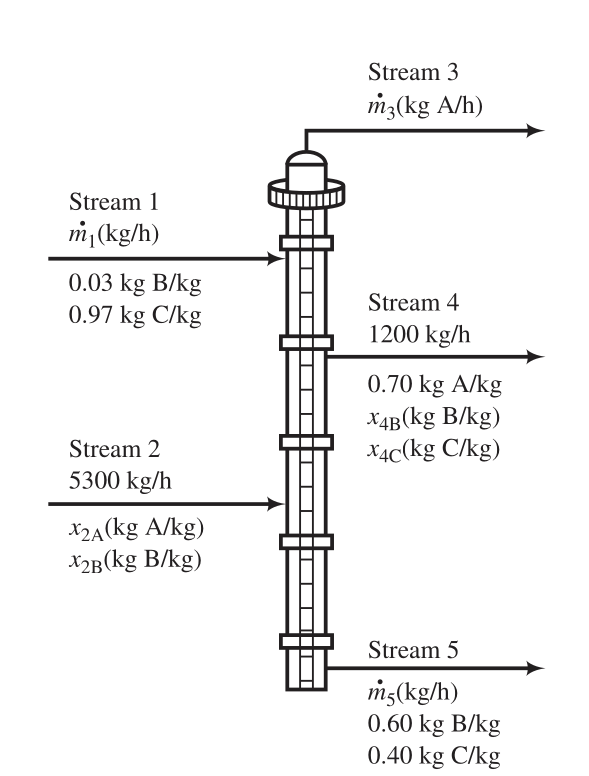